In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import pickle

In [4]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):
    
    current_directory = os.getcwd()
    if current_directory.endswith(directory):
        pass
    else:
        os.chdir(directory)
    #initilize data list
    nematic_parameter = np.zeros(len(aspect_ratios))
    biaxiality = np.zeros(len(aspect_ratios))
    theta_d = np.zeros(len(aspect_ratios))
    phi = np.zeros(len(aspect_ratios))
    bin_centers = np.zeros((len(aspect_ratios), 100))
    pdf_data = np.zeros((len(aspect_ratios), 100)) 
    U_fitted = np.zeros(len(aspect_ratios))

    for idx, ap in enumerate(aspect_ratios):
        filename = f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl'
        if os.path.exists(filename):
            with open(filename, 'rb') as file:
                file_data = pickle.load(file)
                bin_centers[idx, :] = file_data['bin_centers']
                pdf_data[idx, :] = file_data['f_data']
                nematic_parameter[idx] = file_data['nematic_order_parameter']
                biaxiality[idx] = file_data['biaxiality']
                theta_d[idx] = file_data['theta_d']
                U_fitted[idx] = file_data['U_fitted']
                phi[idx] = file_data['phi']

    os.chdir('..') # return to the original directory
    return bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted, phi

def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    accounting for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    numerator = np.exp(S * U * np.cos(2 * measured_thetas))
    integrand = numerator * np.sin(measured_thetas)
    denominator =  4 * np.pi * np.trapezoid(integrand, x=measured_thetas)
    return numerator / denominator

def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 1): return r"$\pi$"
    elif np.isclose(frac, 0.5): return r"$\pi/2$"
    else: return fr"${frac:.2f}\pi$"

Number of colors: 13, Length of colormap: 256, Delta color: 21.0


ValueError: could not broadcast input array from shape (200,) into shape (100,)

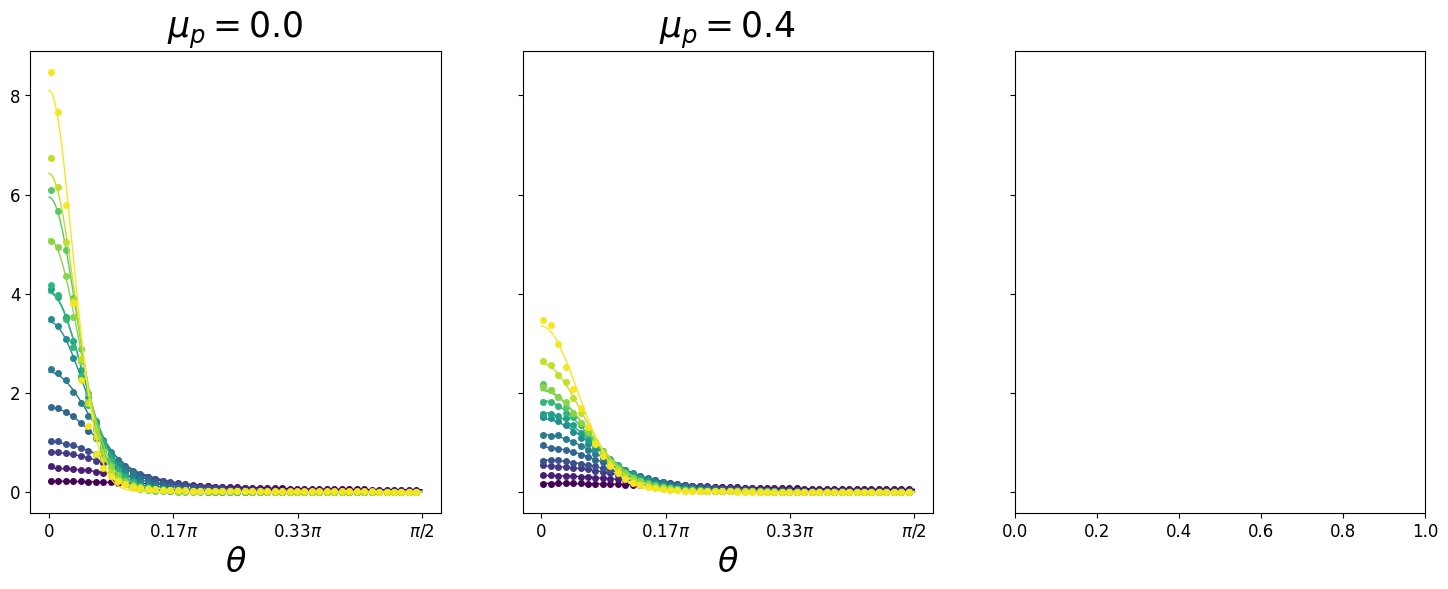

In [6]:
aspect_ratios = np.array([1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 8.0])
# aspect_ratios = np.array([4.5, 5.0, 5.5])

directory = "output_data_hertz"
cof = 0.0
I = 0.1
bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted, phi = read_pdf_theta(directory, cof, I, aspect_ratios)
thetas = np.linspace(0, np.pi / 2, 200)

cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
delta_color = np.floor(length_cmap / (num_colors-1))
print(f"Number of colors: {num_colors}, Length of colormap: {length_cmap}, Delta color: {delta_color}")
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]


cofs = [0.0, 0.4, 10.0]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title
for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    bin_centers, pdf_data, nematic_parameter, biaxiality, theta_d, U_fitted, phi = read_pdf_theta(directory, cof, I, aspect_ratios)
    for i, ap in enumerate(aspect_ratios):
        fitted_odf = fit_equilibrium_ODF(thetas, nematic_parameter[i], U_fitted[i])


        # Plot fitted ODF and PDF data
        ax.plot(thetas, fitted_odf, label=f'$\\alpha={ap}$', linestyle='-', linewidth=1, color=colors[i])
        ax.plot(bin_centers[i, ::2], pdf_data[i, ::2], 'o', linestyle='', markersize=4, color=colors[i])

    ax.set_xlabel('$\\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.2), loc='upper left', ncol=1)

# Set common Y label
axes[0].set_ylabel('$f(\\theta)$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
plt.savefig(f"pdf_comparison_Is_{I}.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
cofs = [0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0]
Is = [0.001, 0.0046, 0.0022, 0.01, 0.046, 0.022, 0.1]
# cofs=[0.0, 0.001]
Is=[0.1]


biaxiality = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
nematic_parameter = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
theta_d = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U_fitted = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phis = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        bin_centers, pdf_data, nematic_parameter_temp, biaxiality_temp, theta_d_temp, U_fitted_temp, phi_temp = read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)
        for i_alpha in range(len(aspect_ratios)):
            biaxiality[i_cof, i_I, i_alpha] = biaxiality_temp[i_alpha]
            nematic_parameter[i_cof, i_I, i_alpha] = nematic_parameter_temp[i_alpha]
            theta_d[i_cof, i_I, i_alpha] = theta_d_temp[i_alpha]
            U_fitted[i_cof, i_I, i_alpha] = U_fitted_temp[i_alpha]
            phis[i_cof, i_I, i_alpha] = phi_temp[i_alpha]

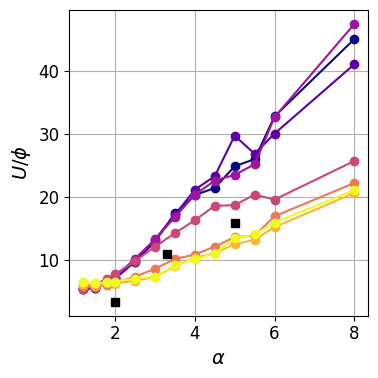

In [23]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.plasma
num_cofs = len(cofs)

U_experimental = np.array([1.2512, 4.108, 5.747]) # the factor 4/3 takes into account the fact I fitted directly p_2
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = phi_dense * (1-3/4*phi_dense) / (1-phi_dense)**2
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U_fitted[i_cof, i_I, :]/phi_dense,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    plt.plot(
        alpha_experimental,
        4/3*U_experimental/phi_experimental,
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    # plt.ylabel("$U  / (\\eta(\\phi) V_{{excl}}) $")#\\phi$")
    plt.ylabel("$U  / \\phi $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    # plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.ylim(0, 2)
    # plt.xlim(1.5, 6.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_unscaled.png", dpi=300, bbox_inches='tight')
    plt.show()

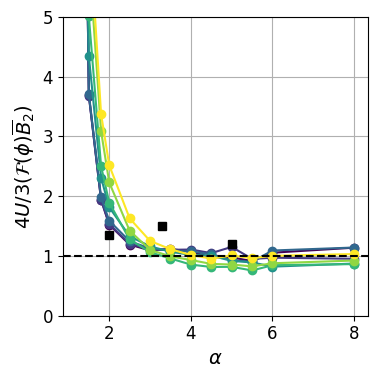

In [21]:
def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor

def parsons_volume_approx(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 /3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term

def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 /32 *np.pi *  (8*alpha / np.pi +2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi) 
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete +second_coeff_B_complete + second_coeff_C_complete)


for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
    # volume_excluded = -second_coeff_excluded_volume(eccentricity)
    volume_excluded = parsons_volume_approx(aspect_ratios)

    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = phi_dense*(1-3/4*phi_dense) / (1-phi_dense)**2
        plt.plot(
            # eccentricity,
            aspect_ratios,
            # U_fitted[i_cof, i_I, :]/phi_dense,
            # U_fitted[i_cof, i_I, :]  / (2* 4/np.pi* aspect_ratios * phi_dense,
            U_fitted[i_cof, i_I, :] /(3/4*volume_excluded*correction_density), #factor 3/4 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
            # U_fitted[i_cof, i_I, :] /(volume_excluded* phi_dense), 
            # U_fitted[i_cof, i_I, :] ,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    # plt.title(f"U_fitted vs epsilon for I = {I_val}")
    plt.xlabel(f"$\\alpha$")
    # plt.ylabel("$U V_p / 2 \\phi \\alpha^2$")#\\phi$")
    plt.ylabel("$4U  / 3(\\mathcal{{F}}(\\phi) \\overline{{B}}_{{2}}) $")#\\phi$")
    # plt.ylabel("$U  / \\phi) $")#\\phi$")
    # plt.xlim(0.7, 1.0)
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    # plt.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Excluded volume/2")
    plt.ylim(0, 5.0)
    # plt.xlim(1.5, 10.0)
    # plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 1.1), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"U_fitted_vs_alpha_I_{I_val}_scaled.png", dpi=300, bbox_inches='tight')
    plt.show()

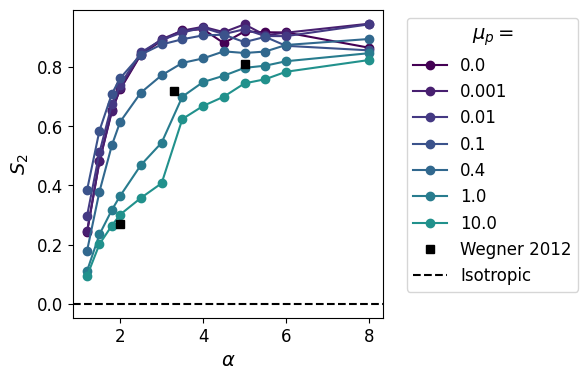

In [20]:
# plot S_2 as a function of aspect ratio for different cof
plt.figure(figsize=(4, 4))
for i_cof, cof_val in enumerate(cofs):
    plt.plot(
        aspect_ratios,
        nematic_parameter[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
plt.plot(alpha_experimental, S2_experimental, 's', label='Wegner 2012', color='black')
plt.xlabel(f"$\\alpha$")
plt.ylabel("$S_2$")
plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
plt.savefig(f"S_2_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_17795/2563355068.py:36: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Scaled alignment potential vs $\mu_p$ (I = {I_val})')


Correction of maier saupe for alpha 1.2 and I 0.1: [0.18796791 0.18834814 0.19130029 0.17620309 0.13723286 0.1198729
 0.11389675]
Correction of maier saupe for alpha 1.5 and I 0.1: [1.08001085 1.08216069 1.08618818 0.98192586 0.73150915 0.58729515
 0.54580318]
Correction of maier saupe for alpha 1.8 and I 0.1: [2.36938034 2.36788875 2.36569018 2.13456435 1.56079174 1.20085372
 1.09154012]
Correction of maier saupe for alpha 2.0 and I 0.1: [3.33051026 3.34020863 3.33186123 2.99371669 2.15503551 1.64087268
 1.46262323]
Correction of maier saupe for alpha 2.5 and I 0.1: [5.99771024 5.99636795 5.97514349 5.2299089  3.70122411 2.73515679
 2.35923016]
Correction of maier saupe for alpha 3.0 and I 0.1: [8.74723113 8.82331669 8.73343447 7.41144031 5.19245387 3.79460106
 3.13249711]
Correction of maier saupe for alpha 3.5 and I 0.1: [11.70653088 11.69791664 11.55239269  9.54481372  6.9060683   5.47795278
  4.67751182]
Correction of maier saupe for alpha 4.0 and I 0.1: [14.44918089 14.53924823 1

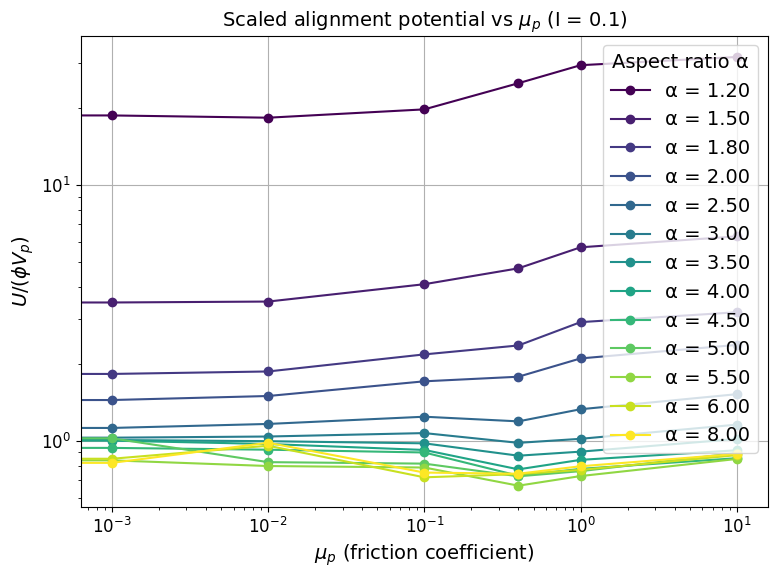

In [16]:
import matplotlib.pyplot as plt


# Color map for different aspect ratios
cmap = plt.cm.viridis
num_alphas = len(aspect_ratios)
colors = [cmap(i / (num_alphas - 1)) for i in range(num_alphas)]

# Plot for each I
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(8, 6))

    for i_alpha, alpha_val in enumerate(aspect_ratios):
        correction_density = phis[:, i_I, i_alpha] * (1 - 3 / 4 * phis[:, i_I, i_alpha]) / (1 - phis[:, i_I, i_alpha])**2
        Vp = 4 * np.pi * alpha_val / 3  # particle volume for prolate ellipsoid
        volume_excluded = -second_coeff_excluded_volume(np.sqrt(1 - 1 / alpha_val**2))
        scaled_U = [
            U_fitted[i_cof, i_I, i_alpha] / phis[i_cof, i_I, i_alpha] / alpha_val
            for i_cof in range(len(cofs))#/ (phis[i_cof, i_I, i_alpha] * Vp)
        ]

        scaled_U = U_fitted[:, i_I, i_alpha] / (volume_excluded * correction_density)
        
        print(f"Correction of maier saupe for alpha {alpha_val} and I {I_val}: {correction_density*volume_excluded}")

        plt.loglog(
            cofs,
            scaled_U,
            marker='o',
            color=colors[i_alpha],
            label=f"α = {alpha_val:.2f}"
        )

    plt.xlabel(r'$\mu_p$ (friction coefficient)')
    plt.ylabel(r'$U / (\phi V_p)$')
    plt.title(f'Scaled alignment potential vs $\mu_p$ (I = {I_val})')
    plt.grid(True)
    plt.legend(title='Aspect ratio α')
    plt.tight_layout()
    plt.show()
   

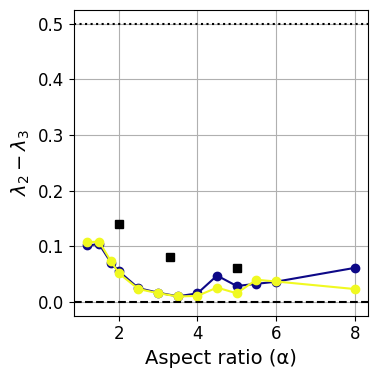

In [9]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

cmap = plt.cm.plasma
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot experimental data
    plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    # plt.title(f"Biaxiality vs α for I = {I_val}")
    plt.xlabel("Aspect ratio (α)")
    plt.ylabel("$\\lambda_2-\\lambda_3$")
    # plt.ylim(-0.0, 0.33)
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    plt.axhline(0.5, color='k', linestyle=':', linewidth=1.5, label="Maximum biaxiality")  
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"biaxiality_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



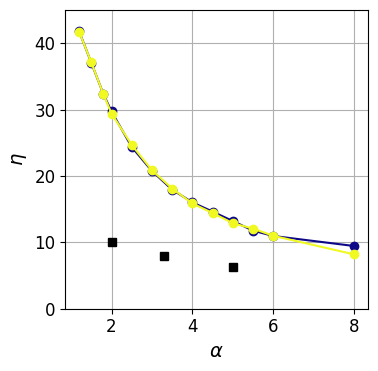

In [10]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')

    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    plt.grid(True)
    plt.ylim([0., 45])
    plt.tight_layout()
    plt.savefig(f"theta_d_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



In [11]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)

        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            ell/beta,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
    # Plot experimental data
    beta_experimental = (alphas_rods_experiments**2 - 1) / (alphas_rods_experiments**2 + 1)
    c_experimental = np.tan(np.deg2rad(theta_d_rods_experiments))**2   
    ell_experimental = (-1 - c_experimental) / (c_experimental-1)
    plt.plot(
        alphas_rods_experiments,
        ell_experimental / beta_experimental,
        's',
        color='black',
        label='Experiments (rods)'
    )

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$ \\alpha$")
    plt.ylabel("$\\lambda / \\beta$")
    # plt.legend(title="$\\mu_p =$")
    plt.grid(True)
    plt.ylim([0., 5])
    plt.tight_layout()
    plt.savefig(f"ericksen_number_vs_epsilon_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



IndentationError: unexpected indent (2434274338.py, line 11)

/tmp/ipykernel_11934/1410363526.py:2: RuntimeWarning: divide by zero encountered in divide
  first_factor = 15 / 32 / x**4
/tmp/ipykernel_11934/1410363526.py:3: RuntimeWarning: divide by zero encountered in arctanh
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_11934/1410363526.py:3: RuntimeWarning: invalid value encountered in multiply
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_11934/1410363526.py:3: RuntimeWarning: invalid value encountered in divide
  second_factor = x**2 - 3 + (x**2+3) * (1- x**2) * np.arctanh(x) / x
/tmp/ipykernel_11934/1410363526.py:4: RuntimeWarning: divide by zero encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
/tmp/ipykernel_11934/1410363526.py:4: RuntimeWarning: invalid value encountered in divide
  third_factor = 3 - 2 * x**2 + (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))


Text(0.5, 1.0, 'Second coefficient of excluded volume as a function of eccentricity')

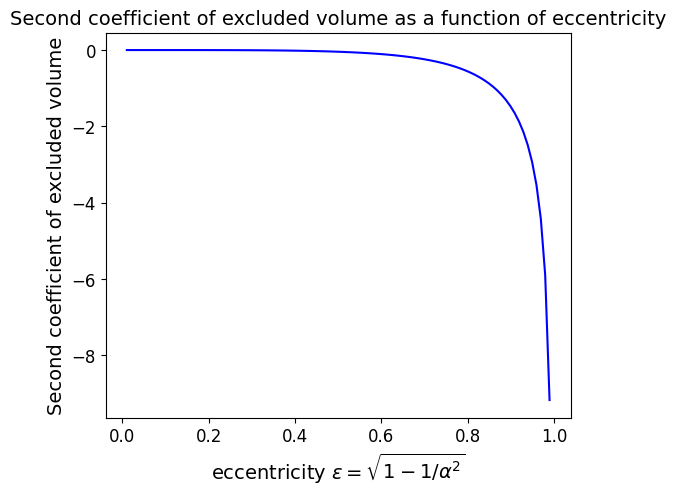

In [32]:
x = np.linspace(0, 1, 100)
plt.figure(figsize=(6, 5))
plt.plot(x, second_coeff_excluded_volume(x), label='Second coefficient of excluded volume', color='blue')
plt.xlabel('eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.ylabel('Second coefficient of excluded volume')
plt.title('Second coefficient of excluded volume as a function of eccentricity')


Text(0.5, 1.0, 'Eccentricity as a function of aspect ratio')

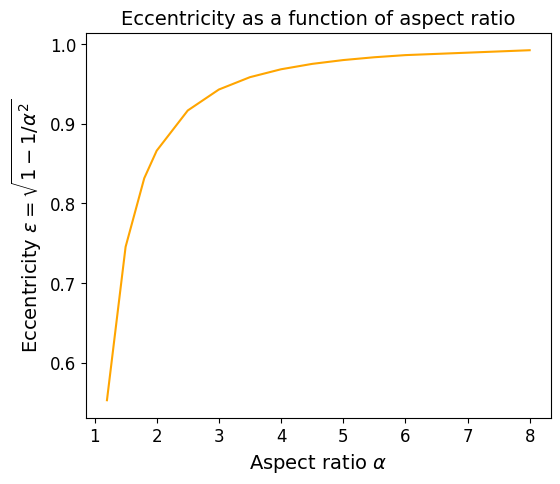

In [33]:
plt.figure(figsize=(6, 5))
plt.plot(aspect_ratios, eccentricity, label='Eccentricity', color='orange')
plt.xlabel('Aspect ratio $\\alpha$')
plt.ylabel('Eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.title('Eccentricity as a function of aspect ratio')

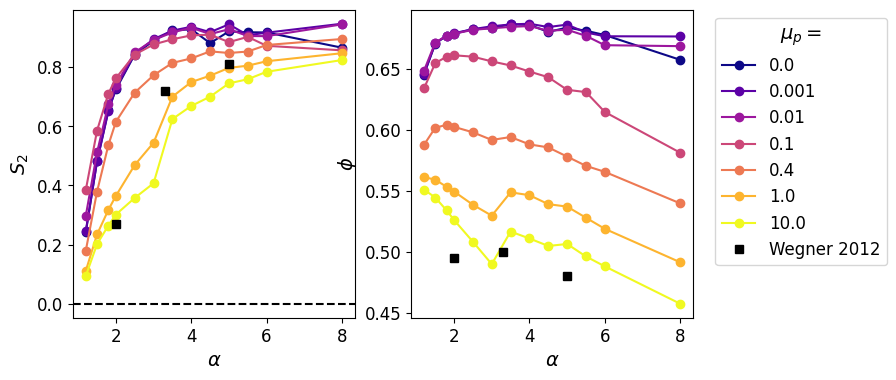

In [31]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
    ax[0].plot(
        aspect_ratios,
        nematic_parameter[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax[0].plot(alpha_experimental, S2_experimental, 's', label='Wegner 2012', color='black')
ax[1].plot(alpha_experimental, phi_experimental, 's', label='Wegner 2012', color='black')
ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$S_2$")
ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$\\phi$")
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
plt.savefig(f"phi_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')